In [1]:
# Back-to-back : le double du PSG en Ligue des champions, chance ou domination ?
# On modelise chaque match par ses xG et on rejoue les campagnes des milliers
# de fois pour separer la performance du resultat.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soccerdata as sd

pd.set_option("display.max_columns", 60)

[09/27/26 00:25:48] INFO     No custom team name replacements found. You can configure these in       ]8;id=10871930;file:///Users/nathanpariente/Documents/psg-back-to-back/.venv/lib/python3.12/site-packages/soccerdata/_config.py\_config.py]8;;\:]8;id=10871931;file:///Users/nathanpariente/Documents/psg-back-to-back/.venv/lib/python3.12/site-packages/soccerdata/_config.py#91\91]8;;\
                             /Users/nathanpariente/soccerdata/config/teamname_replacements.json.                   

                    INFO     Custom league dict loaded from                                          ]8;id=10871937;file:///Users/nathanpariente/Documents/psg-back-to-back/.venv/lib/python3.12/site-packages/soccerdata/_config.py\_config.py]8;;\:]8;id=10871938;file:///Users/nathanpariente/Documents/psg-back-to-back/.venv/lib/python3.12/site-packages/soccerdata/_config.py#187\187]8;;\
                             /Users/nathanpariente/soccerdata/config/league_dict.json.                             

In [2]:
# Les quatre campagnes couvertes par notre source de xG (Sofascore
# publie les xG de LdC depuis 2022-23) : Galtier et la MNM, la premiere
# annee Luis Enrique, puis le back-to-back.
SAISONS = ["2022-2023", "2023-2024", "2024-2025", "2025-2026"]
ldc = sd.FBref(leagues="EUR-Champions League", seasons=SAISONS)

                    INFO     Saving cached data to /Users/nathanpariente/soccerdata/data/FBref       ]8;id=10871945;file:///Users/nathanpariente/Documents/psg-back-to-back/.venv/lib/python3.12/site-packages/soccerdata/_common.py\_common.py]8;;\:]8;id=10871946;file:///Users/nathanpariente/Documents/psg-back-to-back/.venv/lib/python3.12/site-packages/soccerdata/_common.py#250\250]8;;\

In [3]:
# Tous les matchs "de coupe" du PSG sur les quatre saisons, tels que FBref
# les journalise : LdC melee a la Coupe de France, au Trophee des Champions
# et a la Supercoupe. On affiche tout, brut et numerote ; le tri se fait
# a la cellule suivante, adversaire par adversaire, apres verification.
psg_matchs = ldc.read_team_match_stats(stat_type="schedule", team="Paris SG")

liste = psg_matchs.reset_index()
liste = liste[["season", "date", "round", "venue", "opponent", "GF", "GA"]]
liste = liste.sort_values("date").reset_index(drop=True)

print(len(liste), "matchs au total, toutes competitions de coupe confondues")
for i, r in liste.iterrows():
    print(f"{i+1:>2}. [{r['season']}] {str(r['date'])[:10]}  {r['opponent']:<24} {r['GF']}-{r['GA']}  ({r['round']})")

76 matchs au total, toutes competitions de coupe confondues
 1. [2223] 2022-07-31  Nantes                   4-0  (Trophée des Champions)
 2. [2223] 2022-09-06  Juventus                 2-1  (Group stage)
 3. [2223] 2022-09-14  Maccabi Haifa            3-1  (Group stage)
 4. [2223] 2022-10-05  Benfica                  1-1  (Group stage)
 5. [2223] 2022-10-11  Benfica                  1-1  (Group stage)
 6. [2223] 2022-10-25  Maccabi Haifa            7-2  (Group stage)
 7. [2223] 2022-11-02  Juventus                 2-1  (Group stage)
 8. [2223] 2023-01-06  Châteauroux              3-1  (Round of 64)
 9. [2223] 2023-01-23  US Pays de Cassel        7-0  (Round of 32)
10. [2223] 2023-02-08  Marseille                1-2  (Round of 16)
11. [2223] 2023-02-14  Bayern Munich            0-1  (Round of 16)
12. [2223] 2023-03-08  Bayern Munich            0-2  (Round of 16)
13. [2324] 2023-09-19  Dortmund                 2-0  (Group stage)
14. [2324] 2023-10-04  Newcastle                1-4  (Group

In [4]:
# Le journal FBref melange les competitions de coupe du club : LdC, Coupe de
# France, Trophee des Champions, Supercoupe UEFA. Deux filtres : les tours qui
# ne peuvent pas etre de la LdC, puis les adversaires de Coupe de France sur
# les tours ambigus - par couple (saison, adversaire), car Brest, par exemple,
# est adversaire de Coupe en 2324 et de LdC en 2425. Verifie match par match.
HORS_LDC = ["UEFA Super Cup", "Trophée des Champions", "Round of 64", "Round of 32"]
COUPE = [
    ("2223", "Marseille"),
    ("2324", "Brest"), ("2324", "Nice"), ("2324", "Rennes"), ("2324", "Lyon"),
    ("2425", "Le Mans"), ("2425", "Stade Briochin"),
    ("2425", "USL Dunkerque"), ("2425", "Reims"),
]

paires = list(zip(liste["season"].astype(str), liste["opponent"]))
est_coupe = pd.Series([p in COUPE for p in paires], index=liste.index)
exclus = liste[liste["round"].isin(HORS_LDC) | est_coupe]
ldc_psg = liste.drop(exclus.index).reset_index(drop=True)

print(len(exclus), "matchs exclus :")
for _, r in exclus.iterrows():
    print(f"    [{r['season']}] {str(r['date'])[:10]}  {r['opponent']:<22} ({r['round']})")
print()
print(len(ldc_psg), "matchs de LdC retenus")
for i, r in ldc_psg.iterrows():
    print(f"{i+1:>2}. [{r['season']}] {str(r['date'])[:10]}  {r['opponent']:<18} {r['GF']}-{r['GA']}  ({r['round']})")

22 matchs exclus :
    [2223] 2022-07-31  Nantes                 (Trophée des Champions)
    [2223] 2023-01-06  Châteauroux            (Round of 64)
    [2223] 2023-01-23  US Pays de Cassel      (Round of 32)
    [2223] 2023-02-08  Marseille              (Round of 16)
    [2324] 2024-01-03  Toulouse               (Trophée des Champions)
    [2324] 2024-01-07  US Revel               (Round of 64)
    [2324] 2024-01-20  Orléans                (Round of 32)
    [2324] 2024-02-07  Brest                  (Round of 16)
    [2324] 2024-03-13  Nice                   (Quarter-finals)
    [2324] 2024-04-03  Rennes                 (Semi-finals)
    [2324] 2024-05-25  Lyon                   (Final)
    [2425] 2024-12-22  Lens                   (Round of 64)
    [2425] 2025-01-05  Monaco                 (Trophée des Champions)
    [2425] 2025-01-15  FC Espaly              (Round of 32)
    [2425] 2025-02-04  Le Mans                (Round of 16)
    [2425] 2025-02-26  Stade Briochin         (Quarter

In [5]:
# Les xG des 54 matchs, releves a la main sur Sofascore (xG PSG puis xG
# adverse), dans l'ordre chronologique de la liste ci-dessus. Sofascore
# publie les xG de LdC depuis 2022-23, d'ou le perimetre. Deux matchs sont
# alles en prolongation : leur xG couvre 120 minutes, la simulation en
# tiendra compte.

# --- 2022-23, Galtier (8 matchs)
xg_psg_2223 = [1.76, 1.85, 1.03, 1.20, 2.64, 0.54, 0.83, 1.10]
xg_adv_2223 = [1.03, 1.02, 1.39, 1.21, 0.80, 1.56, 1.41, 1.72]

# --- 2023-24, premiere annee Luis Enrique (12 matchs)
xg_psg_2324 = [2.44, 0.93, 1.33, 1.54, 4.54, 2.86, 1.23, 1.40, 1.19, 2.47, 1.70, 3.25]
xg_adv_2324 = [0.66, 0.94, 0.58, 1.45, 1.29, 1.38, 0.67, 0.90, 1.95, 1.08, 1.78, 0.74]

# --- 2024-25, premiere etoile (17 matchs)
xg_psg_2425 = [2.10, 0.40, 2.57, 2.12, 0.77, 3.18, 2.81, 2.41, 2.72,
               3.24, 1.78, 2.63, 1.95, 1.69, 1.16, 1.74, 3.12]
xg_adv_2425 = [0.25, 0.71, 0.25, 0.67, 2.41, 0.15, 1.76, 0.77, 0.96,
               0.97, 0.27, 1.51, 0.74, 2.05, 1.63, 2.91, 0.49]

# --- 2025-26, le back-to-back (17 matchs)
xg_psg_2526 = [3.48, 1.67, 2.86, 1.95, 1.85, 2.22, 1.42, 2.52, 3.09,
               2.21, 0.90, 1.09, 2.35, 1.09, 1.90, 1.06, 1.72]
xg_adv_2526 = [0.55, 1.27, 2.50, 1.53, 1.79, 0.52, 0.89, 1.07, 1.19,
               1.32, 1.57, 1.26, 0.17, 1.97, 3.06, 1.41, 0.51]

matchs = ldc_psg.copy()
matchs["xg_psg"] = xg_psg_2223 + xg_psg_2324 + xg_psg_2425 + xg_psg_2526
matchs["xg_adv"] = xg_adv_2223 + xg_adv_2324 + xg_adv_2425 + xg_adv_2526

PROLONGATIONS = ["2025-03-11", "2026-05-30"]   # Liverpool retour 2025, finale 2026
matchs["prolong"] = matchs["date"].astype(str).str[:10].isin(PROLONGATIONS)

# Controle : xG cumules contre buts reels, saison par saison
bilan = matchs.groupby("season").agg(
    xg_pour=("xg_psg", "sum"), buts_pour=("GF", lambda s: pd.to_numeric(s.astype(str).str[0]).sum()),
    xg_contre=("xg_adv", "sum"), buts_contre=("GA", lambda s: pd.to_numeric(s.astype(str).str[0]).sum()),
).round(1)
print(bilan)
print(matchs["prolong"].sum(), "matchs a prolongation")

        xg_pour  buts_pour  xg_contre  buts_contre
season                                            
2223       11.0         16       10.1           10
2324       24.9         19       13.4           15
2425       36.4         38       18.5           15
2526       33.4         45       22.6           23
2 matchs a prolongation


In [6]:
# Chaque match est rejoue 10 000 fois : les buts du PSG suivent une loi de
# Poisson d'intensite xg_psg, ceux de l'adversaire une Poisson d'intensite
# xg_adv. On fige la performance (les occasions creees), on ne fait varier
# que la finition. Pour les deux matchs a prolongation, le xG couvre 120
# minutes : on le ramene a 90 pour rester comparable.
rng = np.random.default_rng(42)   # graine fixee : resultats reproductibles
N = 10_000

fac = np.where(matchs["prolong"], 90 / 120, 1.0)
lam_psg = matchs["xg_psg"].to_numpy() * fac
lam_adv = matchs["xg_adv"].to_numpy() * fac

# une matrice de 10 000 lignes x 54 matchs : chaque ligne est un "monde"
buts_psg = rng.poisson(lam_psg, size=(N, len(matchs)))
buts_adv = rng.poisson(lam_adv, size=(N, len(matchs)))

matchs["p_victoire"] = (buts_psg > buts_adv).mean(axis=0)
matchs["p_nul"]      = (buts_psg == buts_adv).mean(axis=0)
matchs["p_defaite"]  = (buts_psg < buts_adv).mean(axis=0)

# Le resultat reel, deduit du score (temps reglementaire : le premier
# caractere de GF/GA neutralise les formats "1 (4)" des tirs au but).
matchs["buts_reels"] = pd.to_numeric(matchs["GF"].astype(str).str[0])
matchs["buts_encaisses"] = pd.to_numeric(matchs["GA"].astype(str).str[0])
gf, ga = matchs["buts_reels"], matchs["buts_encaisses"]
res = np.select([gf > ga, gf == ga], ["W", "D"], default="L")

matchs["p_du_resultat_reel"] = np.select(
    [res == "W", res == "D", res == "L"],
    [matchs["p_victoire"], matchs["p_nul"], matchs["p_defaite"]])

colonnes = ["season", "opponent", "round", "buts_reels", "buts_encaisses",
            "xg_psg", "xg_adv", "p_du_resultat_reel"]
print("Les resultats les moins probables (la ou le sort a travaille) :")
print(matchs.sort_values("p_du_resultat_reel")[colonnes].head(6).round(2).to_string(index=False))

Les resultats les moins probables (la ou le sort a travaille) :
season        opponent        round  buts_reels  buts_encaisses  xg_psg  xg_adv  p_du_resultat_reel
  2425       Liverpool  Round of 16           0               1    1.78    0.27                0.05
  2324        Dortmund  Semi-finals           0               1    3.25    0.74                0.06
  2324       Newcastle  Group stage           1               1    4.54    1.29                0.07
  2425 Atlético Madrid League phase           1               2    2.12    0.67                0.10
  2425             PSV League phase           1               1    2.57    0.25                0.10
  2223        Juventus  Group stage           2               1    0.54    1.56                0.13


In [7]:
# L'ecart de finition : buts - xG (attaque : positif = on convertit mieux
# que la normale) et buts encaisses - xG concedes (defense : negatif = on
# encaisse moins que ce qu'on concede). C'est la mesure classique de la
# sur/sous-performance, gardiens inclus.
ecarts = matchs.groupby("season").agg(
    matchs_joues=("date", "count"),
    xg_pour=("xg_psg", "sum"), buts_pour=("buts_reels", "sum"),
    xg_contre=("xg_adv", "sum"), buts_contre=("buts_encaisses", "sum"),
)
ecarts["finition"] = (ecarts["buts_pour"] - ecarts["xg_pour"]).round(1)
ecarts["solidite"] = (ecarts["buts_contre"] - ecarts["xg_contre"]).round(1)
ecarts["finition_par_match"] = (ecarts["finition"] / ecarts["matchs_joues"]).round(2)
print(ecarts.round(1))

        matchs_joues  xg_pour  buts_pour  xg_contre  buts_contre  finition  \
season                                                                       
2223               8     11.0         16       10.1           10       5.0   
2324              12     24.9         19       13.4           15      -5.9   
2425              17     36.4         38       18.5           15       1.6   
2526              17     33.4         45       22.6           23      11.6   

        solidite  finition_par_match  
season                                
2223        -0.1                 0.6  
2324         1.6                -0.5  
2425        -3.5                 0.1  
2526         0.4                 0.7  


In [8]:
# On passe du match a la confrontation : en phase a elimination directe,
# ce qui compte est de se qualifier sur l'ensemble des deux manches (la
# regle du but a l'exterieur n'existe plus). Egalite au cumul ->
# prolongation au match retour (intensites ramenees a 30 min), puis tirs
# au but modelises en 50-50.
KO = ["Knockout phase play-offs", "Round of 16", "Quarter-finals", "Semi-finals", "Final"]
PERDUES = {("2223", "Round of 16"), ("2324", "Semi-finals")}   # les deux eliminations reelles

def proba_confrontation(idx):
    """Part des mondes ou le PSG franchit cette confrontation.
    idx : positions des matchs (2 pour un aller-retour, 1 pour une finale)."""
    a_psg = buts_psg[:, idx].sum(axis=1)
    a_adv = buts_adv[:, idx].sum(axis=1)
    qualif = a_psg > a_adv
    egalite = a_psg == a_adv
    if egalite.sum():
        j = idx[-1]                                  # la prolongation se joue au retour
        et_psg = rng.poisson(lam_psg[j] / 3, egalite.sum())
        et_adv = rng.poisson(lam_adv[j] / 3, egalite.sum())
        issue = et_psg > et_adv
        encore = et_psg == et_adv
        issue[encore] = rng.random(encore.sum()) < 0.5   # tirs au but : 50-50
        qualif[egalite.to_numpy() if hasattr(egalite, "to_numpy") else egalite] = issue
    return qualif.mean()

resume = []
for saison in ["2223", "2324", "2425", "2526"]:
    s = matchs[matchs["season"].astype(str) == saison]
    for tour in KO:
        bloc = s[s["round"] == tour].sort_values("date")
        if len(bloc) == 0:
            continue
        p = proba_confrontation(bloc.index.to_numpy())
        reel = "NON" if (saison, tour) in PERDUES else "oui"
        resume.append([saison, tour, len(bloc), round(p, 3), reel])

resume = pd.DataFrame(resume, columns=["saison", "tour", "matchs", "p_franchir", "franchi_en_vrai"])
print(resume.to_string(index=False))

saison                     tour  matchs  p_franchir franchi_en_vrai
  2223              Round of 16       2       0.288             NON
  2324              Round of 16       2       0.704             oui
  2324           Quarter-finals       2       0.616             oui
  2324              Semi-finals       2       0.836             NON
  2425 Knockout phase play-offs       2       0.944             oui
  2425              Round of 16       2       0.862             oui
  2425           Quarter-finals       2       0.615             oui
  2425              Semi-finals       2       0.272             oui
  2425                    Final       1       0.948             oui
  2526 Knockout phase play-offs       2       0.846             oui
  2526              Round of 16       2       0.353             oui
  2526           Quarter-finals       2       0.688             oui
  2526              Semi-finals       2       0.282             oui
  2526                    Final       1       0.

In [9]:
# Le chiffre de chaque campagne : la probabilite de franchir TOUS les tours
# a elimination directe a la suite (les confrontations sont independantes
# dans le modele, on multiplie). Et pour la phase de ligue / poules : la
# distribution des points simules face aux points reels : on ne simule pas
# le classement (il faudrait les 35 autres equipes), seulement nos points.
print("--- Parcours a elimination directe ---")
produits = {}
for saison in ["2223", "2324", "2425", "2526"]:
    p = resume[resume["saison"] == saison]["p_franchir"].prod()
    produits[saison] = p
    print(f"{saison} : franchir tous les tours joues = {p:.3f}  (1 monde sur {1/p:.0f})")

p_b2b = produits["2425"] * produits["2526"]
print(f"\nLe back-to-back complet : {p_b2b:.4f}  (1 monde sur {1/p_b2b:.0f})")

print("\n--- Phase de ligue / poules : points simules contre points reels ---")
for saison in ["2223", "2324", "2425", "2526"]:
    s = matchs[(matchs["season"].astype(str) == saison) & (~matchs["round"].isin(KO))]
    idx = s.index.to_numpy()
    pts = 3 * (buts_psg[:, idx] > buts_adv[:, idx]) + 1 * (buts_psg[:, idx] == buts_adv[:, idx])
    pts = pts.sum(axis=1)
    reels = int((3 * (s["buts_reels"] > s["buts_encaisses"]) + 1 * (s["buts_reels"] == s["buts_encaisses"])).sum())
    print(f"{saison} : reels {reels} pts | simules {pts.mean():.1f} en moyenne "
          f"| P(faire au moins {reels} pts) = {(pts >= reels).mean():.2f}")

--- Parcours a elimination directe ---
2223 : franchir tous les tours joues = 0.288  (1 monde sur 3)
2324 : franchir tous les tours joues = 0.363  (1 monde sur 3)
2425 : franchir tous les tours joues = 0.129  (1 monde sur 8)
2526 : franchir tous les tours joues = 0.045  (1 monde sur 22)

Le back-to-back complet : 0.0059  (1 monde sur 171)

--- Phase de ligue / poules : points simules contre points reels ---
2223 : reels 14 pts | simules 9.4 en moyenne | P(faire au moins 14 pts) = 0.07
2324 : reels 8 pts | simules 12.1 en moyenne | P(faire au moins 8 pts) = 0.94
2425 : reels 13 pts | simules 16.3 en moyenne | P(faire au moins 13 pts) = 0.91
2526 : reels 14 pts | simules 15.6 en moyenne | P(faire au moins 14 pts) = 0.73


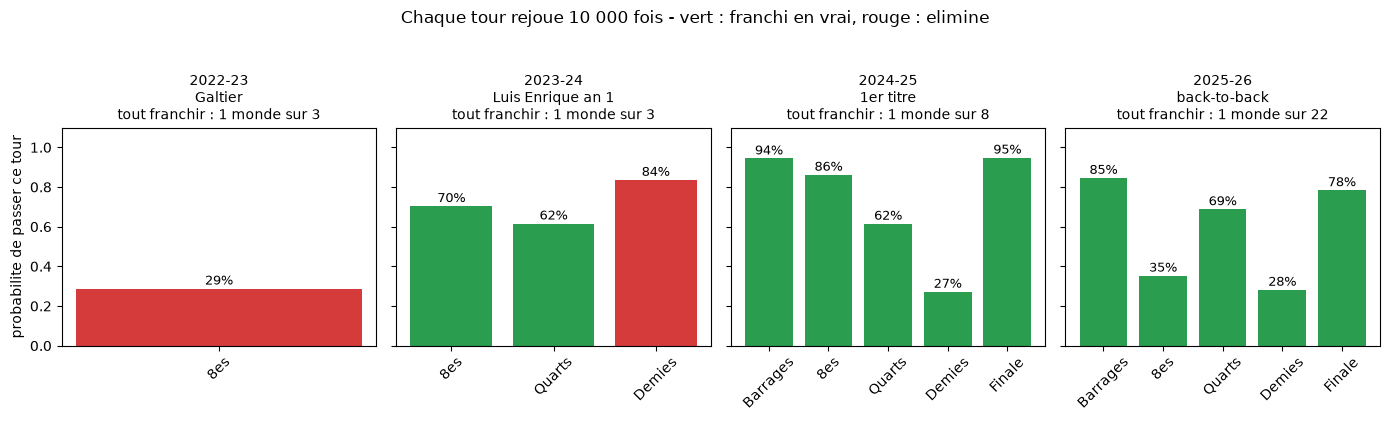

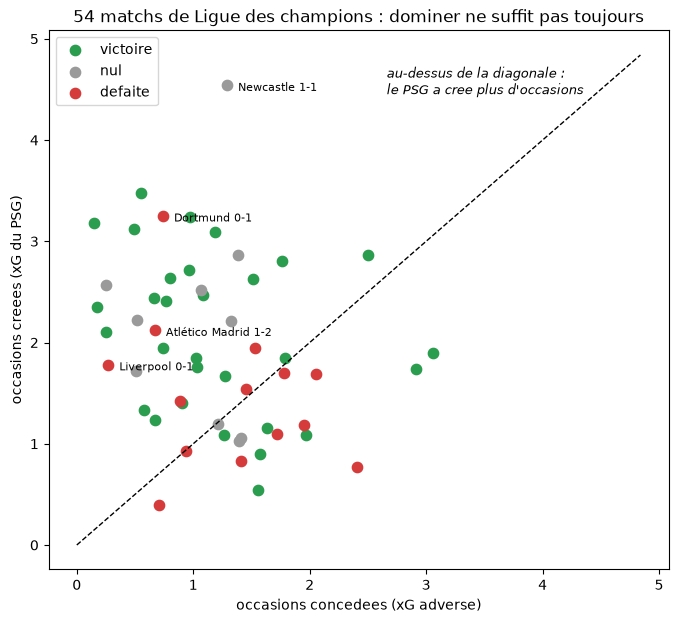

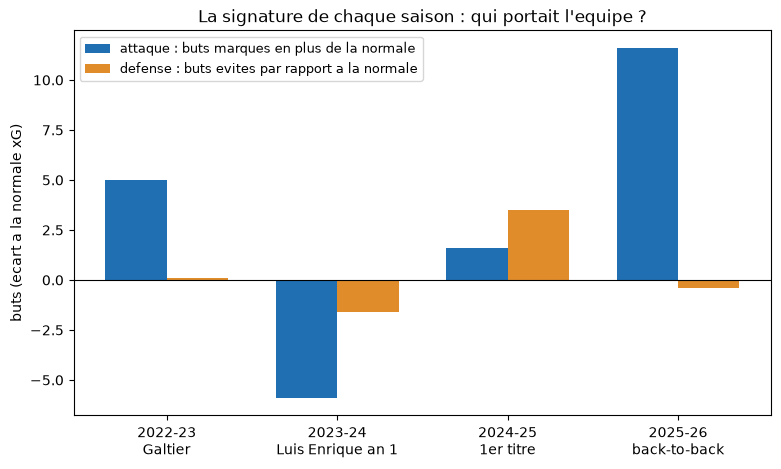

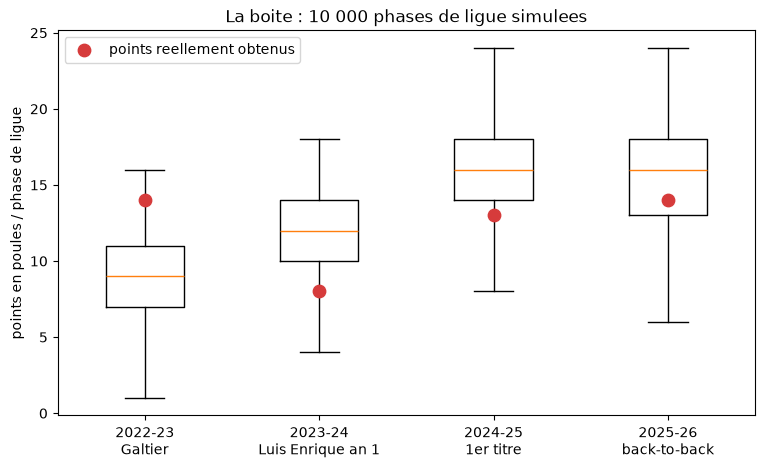

In [10]:
# Les quatre visuels du projet.
# 1. le parcours tour par tour (la ou tout s'est joue)
# 2. chaque match : occasions creees contre occasions concedees
# 3. la signature de chaque saison (finition et solidite)
# 4. les points de phase de ligue : la realite face aux 10 000 mondes

NOM_TOUR = {"Knockout phase play-offs": "Barrages", "Round of 16": "8es",
            "Quarter-finals": "Quarts", "Semi-finals": "Demies", "Final": "Finale"}
NOM_SAISON = {"2223": "2022-23\nGaltier", "2324": "2023-24\nLuis Enrique an 1",
              "2425": "2024-25\n1er titre", "2526": "2025-26\nback-to-back"}
SAISONS_ORDRE = ["2223", "2324", "2425", "2526"]

#Figure 1 : le parcours a elimination directe, tour par tour
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, saison in zip(axes, SAISONS_ORDRE):
    bloc = resume[resume["saison"] == saison]
    couleurs = ["#2a9d4e" if f == "oui" else "#d63b3b" for f in bloc["franchi_en_vrai"]]
    ax.bar([NOM_TOUR[t] for t in bloc["tour"]], bloc["p_franchir"], color=couleurs)
    for x, p in enumerate(bloc["p_franchir"]):
        ax.text(x, p + 0.02, f"{p:.0%}", ha="center", fontsize=9)
    prod = bloc["p_franchir"].prod()
    ax.set_title(f"{NOM_SAISON[saison]}\ntout franchir : 1 monde sur {1/prod:.0f}", fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("probabilite de passer ce tour")
fig.suptitle("Chaque tour rejoue 10 000 fois - vert : franchi en vrai, rouge : elimine", y=1.04)
fig.tight_layout()
fig.savefig("../figures/parcours.png", dpi=150, bbox_inches="tight")
plt.show()

#Figure 2 : chaque match, occasions creees contre concedees
fig, ax = plt.subplots(figsize=(8, 7))
gagne = matchs["buts_reels"] > matchs["buts_encaisses"]
nul   = matchs["buts_reels"] == matchs["buts_encaisses"]
ax.scatter(matchs.loc[gagne, "xg_adv"], matchs.loc[gagne, "xg_psg"], c="#2a9d4e", label="victoire", s=55)
ax.scatter(matchs.loc[nul, "xg_adv"], matchs.loc[nul, "xg_psg"], c="#9a9a9a", label="nul", s=55)
ax.scatter(matchs.loc[~gagne & ~nul, "xg_adv"], matchs.loc[~gagne & ~nul, "xg_psg"],
           c="#d63b3b", label="defaite", s=55)
lim = max(matchs["xg_psg"].max(), matchs["xg_adv"].max()) + 0.3
ax.plot([0, lim], [0, lim], "k--", lw=1)
ax.text(lim * 0.55, lim * 0.92, "au-dessus de la diagonale :\nle PSG a cree plus d'occasions",
        fontsize=9, style="italic")
# les matchs dont on parle : les plus improbables des quatre saisons
a_nommer = matchs.sort_values("p_du_resultat_reel").head(4)
for _, r in a_nommer.iterrows():
    ax.annotate(f"{r['opponent']} {r['buts_reels']}-{r['buts_encaisses']}",
                (r["xg_adv"], r["xg_psg"]), textcoords="offset points",
                xytext=(8, -4), fontsize=8)
ax.set_xlabel("occasions concedees (xG adverse)")
ax.set_ylabel("occasions creees (xG du PSG)")
ax.set_title("54 matchs de Ligue des champions : dominer ne suffit pas toujours")
ax.legend()
fig.savefig("../figures/matchs.png", dpi=150, bbox_inches="tight")
plt.show()

#Figure 3 : la signature de chaque saison
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(SAISONS_ORDRE))
fin = [ecarts.loc[s, "finition"] for s in SAISONS_ORDRE]
sol = [-ecarts.loc[s, "solidite"] for s in SAISONS_ORDRE]   # inverse : positif = bonne defense
ax.bar(x - 0.18, fin, width=0.36, color="#1f6fb2", label="attaque : buts marques en plus de la normale")
ax.bar(x + 0.18, sol, width=0.36, color="#e08c2b", label="defense : buts evites par rapport a la normale")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x, [NOM_SAISON[s] for s in SAISONS_ORDRE])
ax.set_ylabel("buts (ecart a la normale xG)")
ax.set_title("La signature de chaque saison : qui portait l'equipe ?")
ax.legend(fontsize=9)
fig.savefig("../figures/signatures.png", dpi=150, bbox_inches="tight")
plt.show()

#Figure 4 : points de phase de ligue, la realite face aux 10 000 mondes
fig, ax = plt.subplots(figsize=(9, 5))
distributions, reels_liste = [], []
for saison in SAISONS_ORDRE:
    s = matchs[(matchs["season"].astype(str) == saison) & (~matchs["round"].isin(KO))]
    idx = s.index.to_numpy()
    pts = (3 * (buts_psg[:, idx] > buts_adv[:, idx]) + (buts_psg[:, idx] == buts_adv[:, idx])).sum(axis=1)
    distributions.append(pts)
    reels_liste.append(int((3 * (s["buts_reels"] > s["buts_encaisses"])
                            + (s["buts_reels"] == s["buts_encaisses"])).sum()))
bp = ax.boxplot(distributions, tick_labels=[NOM_SAISON[s] for s in SAISONS_ORDRE], showfliers=False)
ax.scatter(range(1, 5), reels_liste, color="#d63b3b", zorder=5, s=80, label="points reellement obtenus")
ax.set_ylabel("points en poules / phase de ligue")
ax.set_title("La boite : 10 000 phases de ligue simulees")
ax.legend()
fig.savefig("../figures/points_ligue.png", dpi=150, bbox_inches="tight")
plt.show()